In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, confusion_matrix, accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("./loan_approval.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(4000, 11)

In [4]:
df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'CreditHistory', 'Dependents', 'Education',
       'EmploymentType', 'PropertyArea', 'MaritalStatus', 'Loan_Status'],
      dtype='str')

In [5]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,Not Graduate,Self Employed,Semiurban,Single,1
1,146932,72084,205887,120,0,1,Graduate,Salaried,Semiurban,Married,1
2,118694,40149,265572,180,1,3+,Graduate,Self Employed,Rural,Single,1
3,134879,27526,144348,36,1,0,Not Graduate,Self Employed,Urban,Single,1
4,125268,68477,155736,240,1,3+,Not Graduate,Self Employed,Urban,Single,1


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
CreditHistory        0
Dependents           0
Education            0
EmploymentType       0
PropertyArea         0
MaritalStatus        0
Loan_Status          0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ApplicantIncome    4000 non-null   int64
 1   CoapplicantIncome  4000 non-null   int64
 2   LoanAmount         4000 non-null   int64
 3   Loan_Amount_Term   4000 non-null   int64
 4   CreditHistory      4000 non-null   int64
 5   Dependents         4000 non-null   str  
 6   Education          4000 non-null   str  
 7   EmploymentType     4000 non-null   str  
 8   PropertyArea       4000 non-null   str  
 9   MaritalStatus      4000 non-null   str  
 10  Loan_Status        4000 non-null   int64
dtypes: int64(6), str(5)
memory usage: 343.9 KB


In [9]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Loan_Status
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000
mean,82404.366000,39191.448500,274527.928500,130.887000,0.754500,0.83675
std,39198.475219,23315.772335,128765.760647,96.149656,0.430437,0.36964
min,15126.000000,2.000000,50015.000000,12.000000,0.000000,0.00000
25%,48217.750000,19071.000000,163228.000000,60.000000,1.000000,1.00000
50%,82401.000000,38617.000000,276918.000000,120.000000,1.000000,1.00000
75%,116021.750000,59256.750000,384040.750000,240.000000,1.000000,1.00000
max,149869.000000,79980.000000,499998.000000,300.000000,1.000000,1.00000


## 2. Outlier Analysis

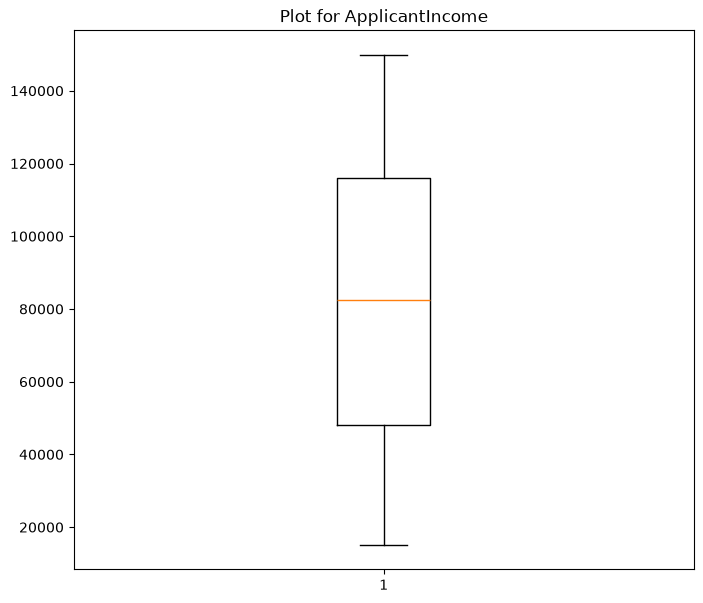

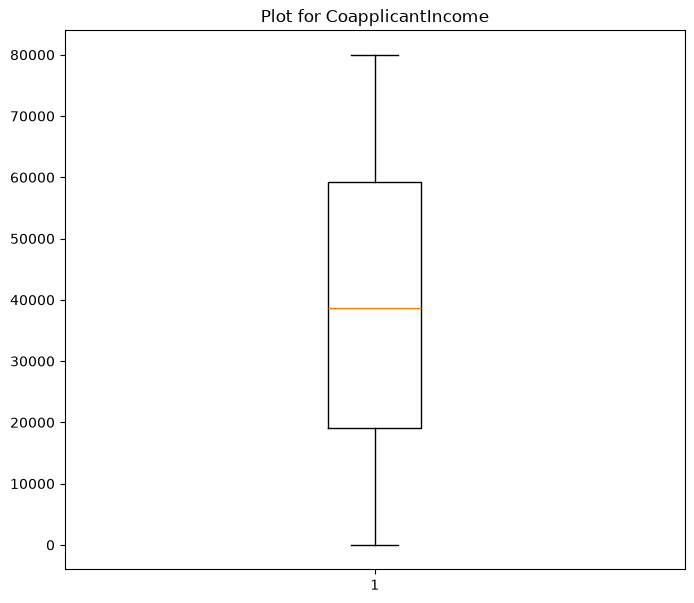

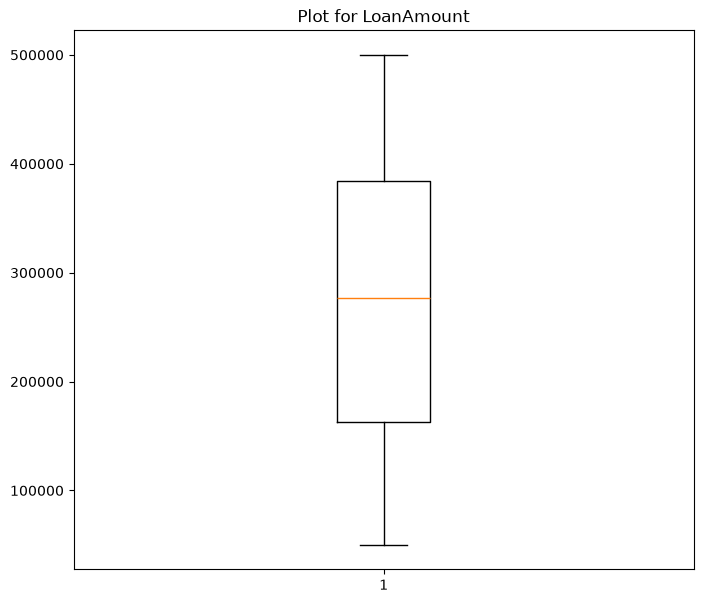

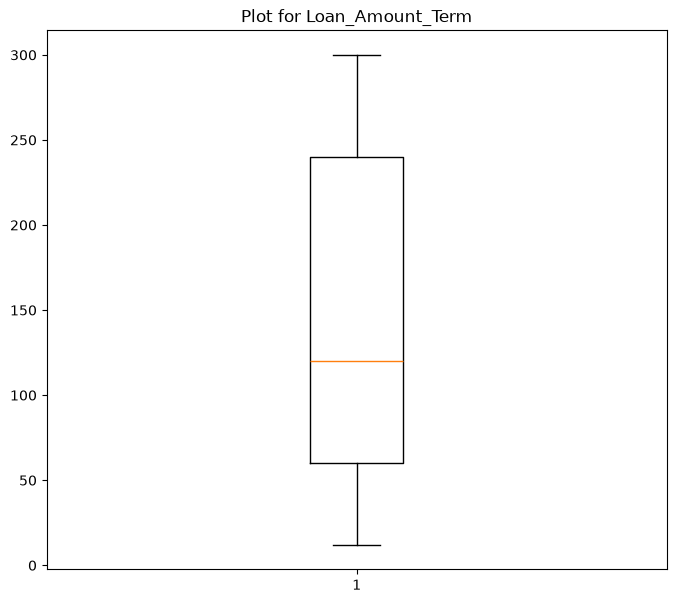

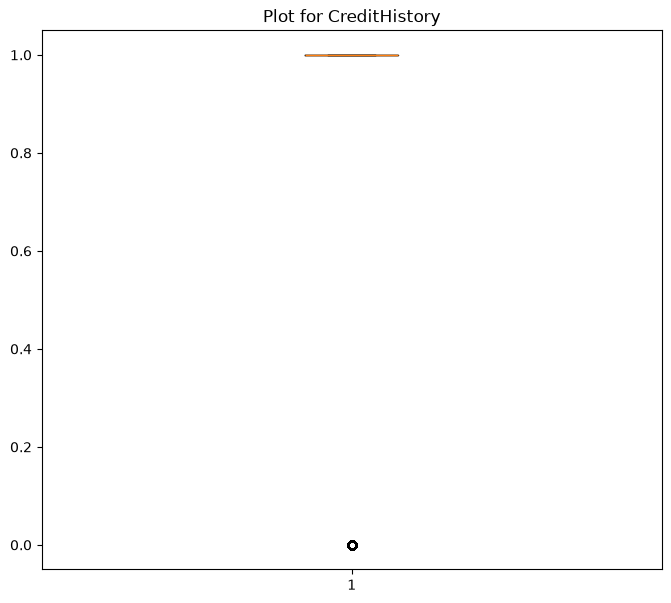

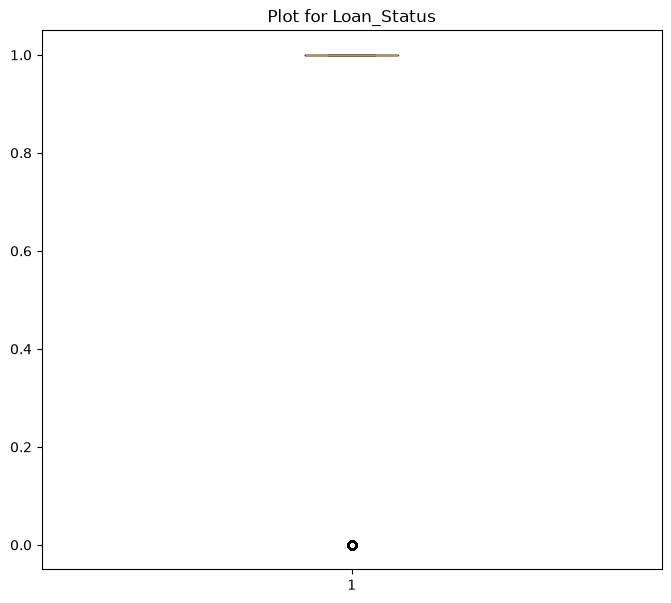

In [10]:
for col in df.select_dtypes(include="number"):
    plt.figure(figsize=(8,7))
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

## 3. Encoding the category columns

In [11]:
cat_col = df.select_dtypes(include="str")
cat_col.columns

Index(['Dependents', 'Education', 'EmploymentType', 'PropertyArea',
       'MaritalStatus'],
      dtype='str')

In [18]:
df["Education"].unique()

<StringArray>
['Not Graduate', 'Graduate']
Length: 2, dtype: str

Label encoding the education and employment type because they have binary values

In [19]:
dfcopy = df.copy()

In [21]:
le = LabelEncoder()

dfcopy["Education"] = le.fit_transform(dfcopy["Education"])

dfcopy["Education"].unique()

array([1, 0])

In [22]:
dfcopy["EmploymentType"] = le.fit_transform(dfcopy["EmploymentType"])

dfcopy["EmploymentType"].unique()

array([1, 0])

One Hot encoding the marital status, dependents ad property are because they have multiple values

In [23]:
dfcopy = pd.get_dummies(dfcopy, 
                        columns=['Dependents', 'PropertyArea', 'MaritalStatus'], 
                        drop_first=True)

dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Education,EmploymentType,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,PropertyArea_Semiurban,PropertyArea_Urban,MaritalStatus_Single
0,136958,50772,298430,300,1,1,1,1,False,True,False,True,False,True
1,146932,72084,205887,120,0,0,0,1,True,False,False,True,False,False
2,118694,40149,265572,180,1,0,1,1,False,False,True,False,False,True
3,134879,27526,144348,36,1,1,1,1,False,False,False,False,True,True
4,125268,68477,155736,240,1,1,1,1,False,False,True,False,True,True


## 4. Preparing the data for the model

In [24]:
X = dfcopy.drop("Loan_Status", axis=1)
y = dfcopy["Loan_Status"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3200, 13)
(800, 13)
(3200,)
(800,)


## 5. Creating the models

In [39]:
dec_model = DecisionTreeRegressor(
    random_state=42,
    max_depth= 5,
    min_samples_leaf=6,
    min_samples_split=10
)

dec_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

In [28]:
log_model = LogisticRegression(max_iter=800)

log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",800
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [29]:
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0. , 0. ,-0. ,...,-0.01,-0.01, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['ApplicantIncome','CoapplicantIncome','LoanAmount',..., 'PropertyArea_Semiurban','PropertyArea_Urban','MaritalStatus_Single']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3527
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


## 6 Checking the parameters and performance of the models

In [40]:
dec_pred = dec_model.predict(X_test)

print("Decision tree metrics: \n ")
print("R2 score: ", r2_score(y_test, dec_pred))
print("MAE: ", mean_absolute_error(y_test, dec_pred))
print("MSE: ", mean_squared_error(y_test, dec_pred))
print("RMSE: ", root_mean_squared_error(y_test, dec_pred))

Decision tree metrics: 
 
R2 score:  0.7225689742036119
MAE:  0.0680879485627367
MSE:  0.039828258154916155
RMSE:  0.19957018353179953


In [41]:
lin_pred = lin_model.predict(X_test)

print("Multiple regression metrics: \n ")
print("R2 score: ", r2_score(y_test, lin_pred))
print("MAE: ", mean_absolute_error(y_test, lin_pred))
print("MSE: ", mean_squared_error(y_test, lin_pred))
print("RMSE: ", root_mean_squared_error(y_test, lin_pred))

Multiple regression metrics: 
 
R2 score:  0.5261739281042517
MAE:  0.17515345323089068
MSE:  0.06802291509329604
RMSE:  0.2608120301928115


Accuracy score:  0.92

 Confusion matrix: 
  [[114  25]
 [ 39 622]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       139
           1       0.96      0.94      0.95       661

    accuracy                           0.92       800
   macro avg       0.85      0.88      0.87       800
weighted avg       0.92      0.92      0.92       800

ROC AUC:  0.9644097127744098


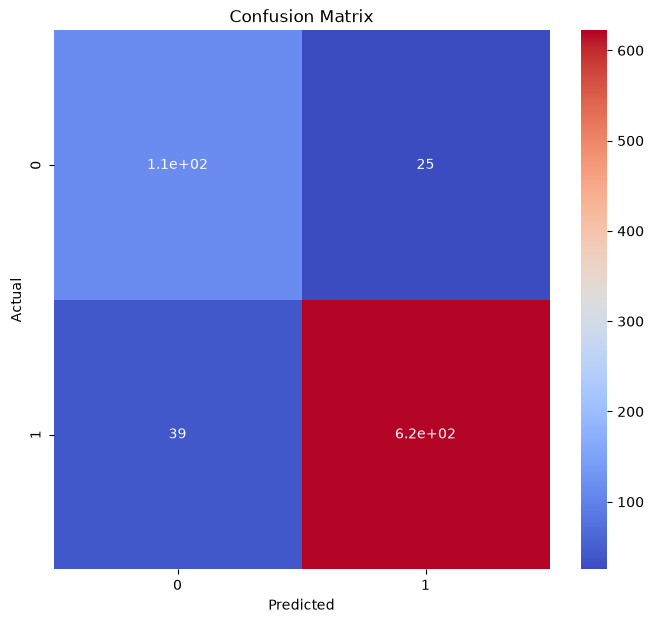

In [42]:
log_pred = log_model.predict(X_test)
log_pred_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)
print("\n Confusion matrix: \n ", cm)

print("Classification Report: \n", classification_report(y_test, log_pred))

roc_auc = roc_auc_score(y_test, log_pred_prob)
print("ROC AUC: ", roc_auc)

plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Visualization of the models

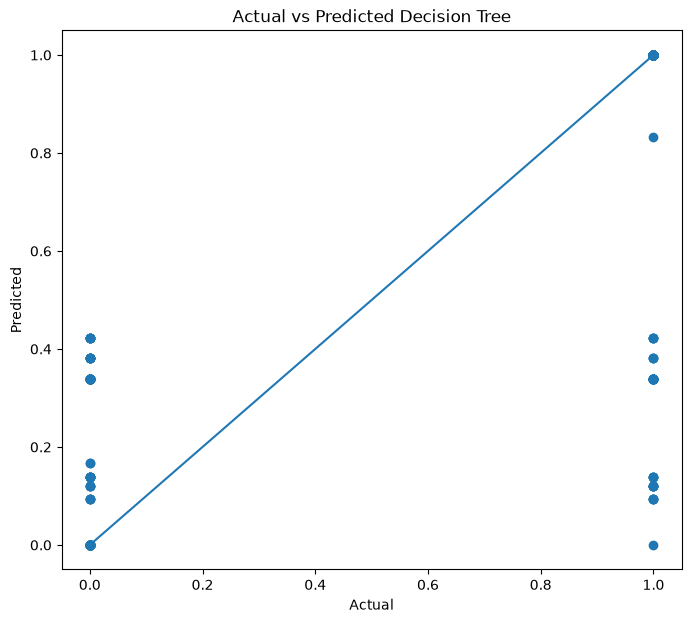

In [43]:
plt.figure(figsize=(8,7))
plt.scatter(y_test, dec_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Decision Tree")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

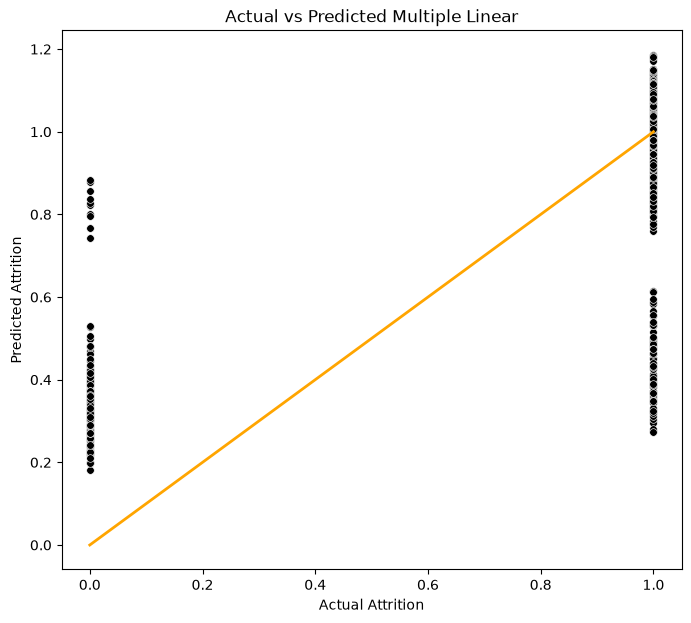

In [ ]:
plt.figure(figsize=(8,7))   
sns.scatterplot(x=y_test, y=lin_pred, s=30, color="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, color="orange")
plt.title("Actual vs Predicted Multiple Linear")
plt.xlabel("Actual Attrition")
plt.ylabel("Predicted Attrition")
plt.show()

In [45]:
dfcopy.head(1)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Education,EmploymentType,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,PropertyArea_Semiurban,PropertyArea_Urban,MaritalStatus_Single
0,136958,50772,298430,300,1,1,1,1,False,True,False,True,False,True


In [47]:
test_applicant_approved = pd.DataFrame({
    'ApplicantIncome': [120000],
    'CoapplicantIncome': [45000],
    'LoanAmount': [250000],
    'Loan_Amount_Term': [360],
    'CreditHistory': [1],
    'Education': [1],
    'EmploymentType': [1],

    'Dependents_1': [False],
    'Dependents_2': [True],
    'Dependents_3+': [False],

    'PropertyArea_Semiurban': [True],
    'PropertyArea_Urban': [False],

    'MaritalStatus_Single': [False]
})

In [48]:
dec_result = dec_model.predict(test_applicant_approved)

print("Predicted loan decision tree: ", dec_result[0])

Predicted loan decision tree:  1.0


In [49]:
lin_result = lin_model.predict(test_applicant_approved)

print("Predicted loan linear regression: ", dec_result[0])

Predicted loan linear regression:  1.0


In [50]:
log_result = log_model.predict(test_applicant_approved)

print("Predicted loan logistic regression: ", dec_result[0])

Predicted loan logistic regression:  1.0
